In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [7]:
import pandas as pd

data = pd.read_csv(
    r"C:\Users\vaish\Downloads\IMDb Movies India.csv (1).zip",
    encoding='latin1'
)

data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [9]:
data.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [25]:
X = data[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']]
y = data['Rating']


In [11]:
print(data.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [12]:
data = data.fillna("Unknown")

In [16]:
data['Actor 1'] = le.fit_transform(data['Actor 1'])
data['Actor 2'] = le.fit_transform(data['Actor 2'])
data['Actor 3'] = le.fit_transform(data['Actor 3'])

In [18]:
print(data['Rating'].dtype)
print(data['Rating'].head(10))

object
0    Unknown
1        7.0
2    Unknown
3        4.4
4    Unknown
5        4.7
6        7.4
7    Unknown
8        5.6
9        4.0
Name: Rating, dtype: object


In [19]:
data['Rating'] = pd.to_numeric(data['Rating'], errors='coerce')

In [20]:
data = data.dropna(subset=['Rating'])

In [21]:
print(data['Rating'].dtype)
print(data['Rating'].isnull().sum())

float64
0


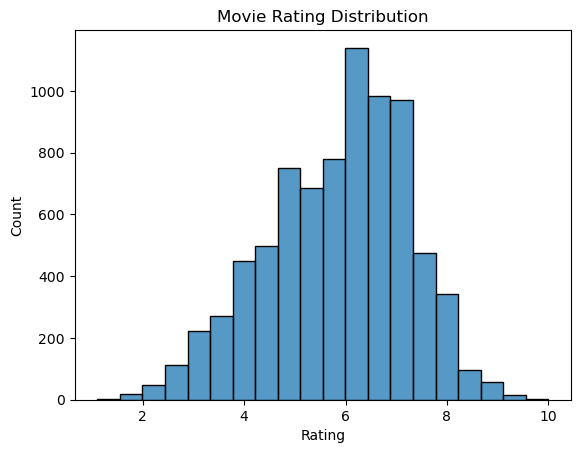

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=data, x='Rating', bins=20)

plt.title("Movie Rating Distribution")
plt.show()

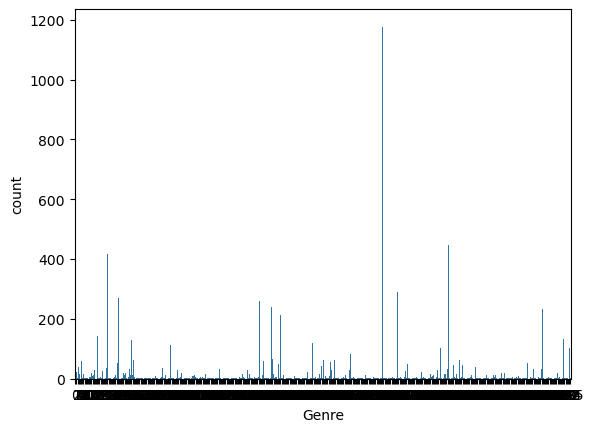

In [23]:
sns.countplot(x='Genre', data=data)

plt.show()

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE =", mean_absolute_error(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score =", r2_score(y_test, y_pred))

MAE = 1.0235622474747477
RMSE = 1.2846092347166365
R2 Score = 0.11237651658066239


In [31]:
data = data.dropna(subset=['Rating'])

In [32]:
print(data['Rating'].isnull().sum())

0


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

In [36]:
y_pred = model.predict(X_test)

In [37]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.021679931758057


In [38]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.12148541020230808


In [39]:
result = pd.DataFrame({
    'Actual Rating': y_test,
    'Predicted Rating': y_pred
})

result.head()

,Actual Rating,Predicted Rating
9456,3.3,5.463
14816,5.3,5.555
3213,5.7,5.471
3778,7.2,6.366
5775,3.5,4.548


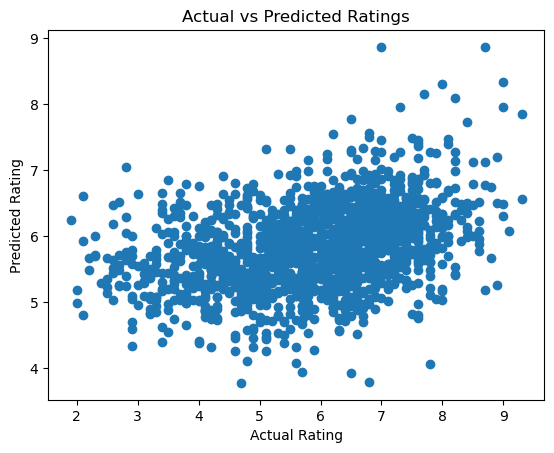

In [40]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rating")

plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings")

plt.show()

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.021679931758057
RMSE: 1.2780008335701312
R2 Score: 0.12148541020230808
